In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Bidirectional
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Vocabulary size
vocab_size = 10000

# Maximum review length
max_length = 200

# Load dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples :", len(X_train))
print("Testing samples :", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples : 25000
Testing samples : 25000


In [3]:
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


In [4]:
simple_rnn = Sequential()

simple_rnn.add(Embedding(input_dim=vocab_size,
                         output_dim=128,
                         input_length=max_length))

simple_rnn.add(SimpleRNN(64))

simple_rnn.add(Dense(1, activation='sigmoid'))

simple_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
simple_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
history_rnn = simple_rnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.6265 - loss: 0.6218 - val_accuracy: 0.7644 - val_loss: 0.5153
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step - accuracy: 0.8317 - loss: 0.3800 - val_accuracy: 0.7652 - val_loss: 0.5098
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.9263 - loss: 0.1925 - val_accuracy: 0.7968 - val_loss: 0.5308
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.9755 - loss: 0.0751 - val_accuracy: 0.7916 - val_loss: 0.6076
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 64ms/step - accuracy: 0.9944 - loss: 0.0236 - val_accuracy: 0.7692 - val_loss: 0.7931


In [7]:
loss_rnn, accuracy_rnn = simple_rnn.evaluate(X_test, y_test)

print("Simple RNN Accuracy:", accuracy_rnn)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7694 - loss: 0.8071
Simple RNN Accuracy: 0.7694399952888489


In [8]:
pred_rnn = simple_rnn.predict(X_test)

pred_rnn = (pred_rnn > 0.5).astype(int)

print(classification_report(y_test, pred_rnn))

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step
              precision    recall  f1-score   support

           0       0.76      0.78      0.77     12500
           1       0.78      0.76      0.77     12500

    accuracy                           0.77     25000
   macro avg       0.77      0.77      0.77     25000
weighted avg       0.77      0.77      0.77     25000



In [9]:
birnn = Sequential()

birnn.add(Embedding(input_dim=vocab_size,
                    output_dim=128,
                    input_length=max_length))

birnn.add(Bidirectional(SimpleRNN(64)))

birnn.add(Dense(1, activation='sigmoid'))

birnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
birnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
history_birnn = birnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 135ms/step - accuracy: 0.6173 - loss: 0.6395 - val_accuracy: 0.7284 - val_loss: 0.5376
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 145ms/step - accuracy: 0.7706 - loss: 0.4882 - val_accuracy: 0.7462 - val_loss: 0.5095
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 107ms/step - accuracy: 0.8436 - loss: 0.3612 - val_accuracy: 0.8286 - val_loss: 0.4172
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 112ms/step - accuracy: 0.8805 - loss: 0.2950 - val_accuracy: 0.8072 - val_loss: 0.4986
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.9215 - loss: 0.2055 - val_accuracy: 0.8068 - val_loss: 0.4740


In [12]:
loss_birnn, accuracy_birnn = birnn.evaluate(X_test, y_test)

print("Bidirectional RNN Accuracy:", accuracy_birnn)

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8096 - loss: 0.4708
Bidirectional RNN Accuracy: 0.8095999956130981


In [13]:
pred_birnn = birnn.predict(X_test)

pred_birnn = (pred_birnn > 0.5).astype(int)

print(classification_report(y_test, pred_birnn))

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step
              precision    recall  f1-score   support

           0       0.81      0.81      0.81     12500
           1       0.81      0.81      0.81     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000



In [14]:
print("Simple RNN Accuracy      :", accuracy_rnn)
print("Bidirectional Accuracy   :", accuracy_birnn)

Simple RNN Accuracy      : 0.7694399952888489
Bidirectional Accuracy   : 0.8095999956130981


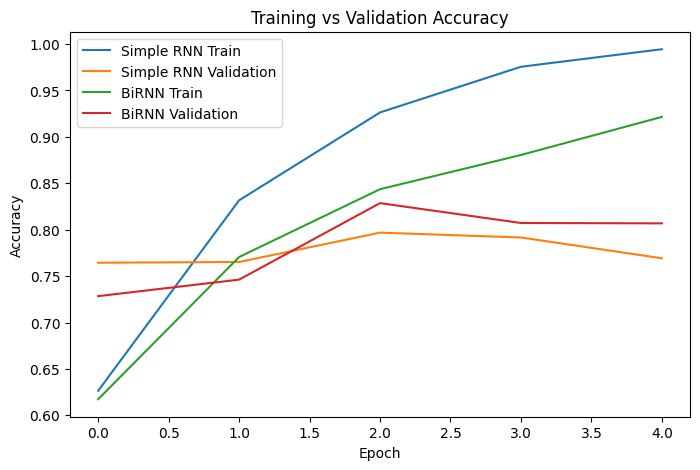

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['accuracy'], label='Simple RNN Train')
plt.plot(history_rnn.history['val_accuracy'], label='Simple RNN Validation')

plt.plot(history_birnn.history['accuracy'], label='BiRNN Train')
plt.plot(history_birnn.history['val_accuracy'], label='BiRNN Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

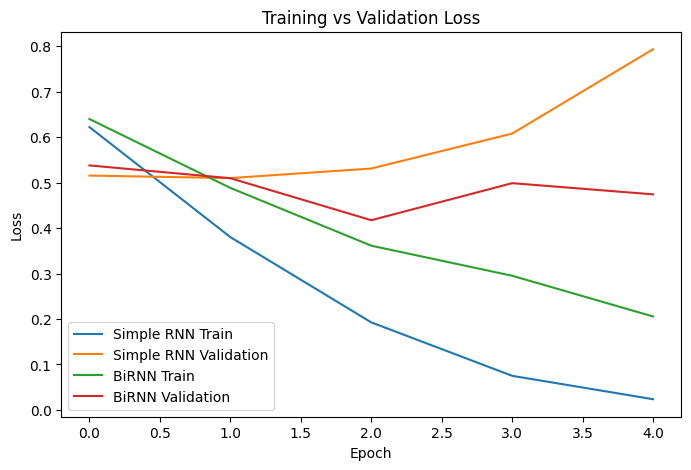

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label='Simple RNN Train')
plt.plot(history_rnn.history['val_loss'], label='Simple RNN Validation')

plt.plot(history_birnn.history['loss'], label='BiRNN Train')
plt.plot(history_birnn.history['val_loss'], label='BiRNN Validation')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()